In [1]:
import os
import json
from collections import defaultdict

import gensim
import gensim.downloader as api
from gensim.models import Word2Vec
import networkx as nx
from tqdm import tqdm
from nltk.corpus import wordnet as wn
import nltk
from matplotlib import pyplot as plt
import numpy as np

### Graph Exploratory Analysis

In [2]:
graph_weighted = nx.read_gexf('graph_weighted_with_probs.gexf')
graph_original = nx.read_gexf('pos_tagged_graph_original.gexf')

In [8]:
# get cycles that are greater than len 2
cycle_lengths = []
sample_cycles = []
cutoff = 20000
i = 0
for cycle in tqdm(nx.simple_cycles(graph_weighted, length_bound=9000)):
    if len(cycle) > 2:
        if np.random.uniform(0,1) < 0.01:
            sample_cycles.append(cycle)
    cycle_lengths.append(len(cycle))
    i += 1
    
    if i > cutoff:
        break
        

20000it [23:57, 13.91it/s]


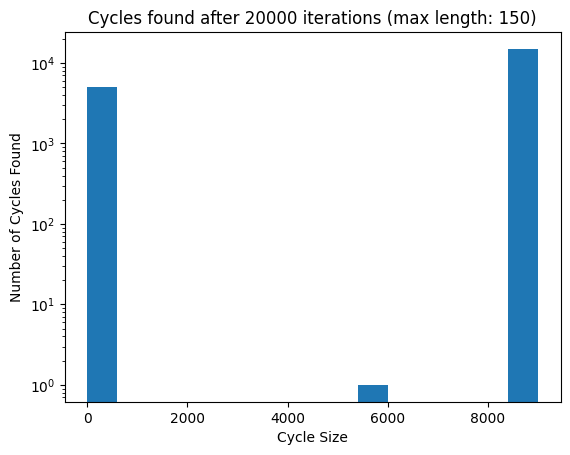

In [9]:
plt.hist(cycle_lengths, bins=15)
plt.yscale('log')
plt.title("Cycles found after 20000 iterations (max length: 9000)")
plt.xlabel("Cycle Size")
plt.ylabel("Number of Cycles Found")
plt.savefig('Figures/cycles_max_len_9000_20000its')

### Evaluation

In [3]:
import pandas as pd

In [4]:
models = {}
models['google_word2vec'] = api.load('word2vec-google-news-300')
models['weighted_window3'] = Word2Vec.load("embeddings.model").wv
models['weighted_window5'] = Word2Vec.load("embeddings5.model").wv
models['unweighted'] = Word2Vec.load("unweighted_graph_embeddings.model").wv

In [5]:
def get_nodes(graph, word, *pos_info):
    nodes = [n for n, d in graph.nodes(data=True) if 'label' in d and f"'{word.lower()}'" in d['label']]
    if len(pos_info) == 0:
        return nodes

    valid_nodes = []
    for node in nodes:
        match = True
        for item in pos_info:
            if f"'{item}'" not in node:
                match=False
                break
        if match:
            valid_nodes.append(node)

    return valid_nodes

#### Analogies

##### Prep

In [6]:
# read in anaogies
analogies_folder = 'Analogies'
analogies_master = {}
for analogy_file in os.listdir(analogies_folder):
    category = analogy_file[:-4]
    analogies_master[category] = pd.read_table(os.path.join(analogies_folder, analogy_file), sep=" ", header=None)
    analogies_master[category].columns = ['w1', 'r1', 'w2', 'r2']
    

In [7]:
# get and save a list of all nodes for words in the analogies
word_to_nodes = {}
words_not_in_graph = []
for category, tests in analogies_master.items():
    for ind, row in tqdm(tests.iterrows(), category, total=len(tests)):
        for word in row:
            if word not in word_to_nodes.keys():
                nodes = [node for node in get_nodes(graph_weighted, word) if "'UNK_POS'" not in node]
                if len(nodes) == 0:
                    words_not_in_graph.append(word)
                word_to_nodes[word] = nodes


superlative: 100%|████████████████████████████████████████████████████████████████| 1122/1122 [00:03<00:00, 355.60it/s]


In [8]:
for category, tests in analogies_master.items():
    analogies_master[category] = tests[~tests.isin(words_not_in_graph).any(axis=1)]

In [9]:
# save a list of nodes associated with each word in the tests
with open('word_to_nodes.json', 'w') as json_file:
    json.dump(word_to_nodes, json_file)

##### Tests

In [10]:
with open('word_to_nodes.json', 'r') as json_file:
    word_to_nodes = json.load(json_file)

In [78]:
google_words = set([word.lower() for word in models['google_word2vec'].index_to_key])

In [79]:
# create lists of analogies, but in a format of the embeddings models can take. 
# for graphical models, this generates analogies using nodes.
# for google, this generates analogies using words themselves.
# filters out analogies that have words that are either not in the graph or not in google's list
analogy_nodes = defaultdict(list)
analogy_google = defaultdict(list)
for category, tests in analogies_master.items():
    for ind, row in tqdm(tests.iterrows(), category, total=len(tests)):
        w1, r1, w2, r2 = row
        w1_nodes = word_to_nodes[w1]
        r1_nodes = word_to_nodes[r1]
        w2_nodes = word_to_nodes[w2]
        r2_nodes = word_to_nodes[r2]

        nodes1_3 = set()
        for node1 in w1_nodes:     # for each node that is the first word in the analogy
            try:
                node3 = [node for node in w2_nodes if eval(node)[1:] == eval(node1)[1:]][0]    # find the node for the third word that has the same pos
                nodes1_3.add((node1, node3))
            except IndexError:
                continue
            
            
        nodes2_4 = set() 
        for node2 in r1_nodes:    # then for each word that is the second word in the analogy
            try:
                node4 = [node for node in r2_nodes if eval(node)[1:] == eval(node2)[1:]][0]    # find the node for the third word that has the same pos
                nodes2_4.add((node2, node4))
            except IndexError:
                continue

        for node1, node3 in nodes1_3:
            for node2, node4 in nodes2_4:
                if (eval(node1)[0] in google_words) and (eval(node2)[0] in google_words) \
                        and (eval(node3)[0] in google_words) and (eval(node4)[0] in google_words):
                    
                    analogy_nodes[category].append((node1, node2, node3, node4))
                    analogy_google[category].append((w1, r1, w2, r2))
                    
                    
            

superlative: 100%|█████████████████████████████████████████████████████████████████| 992/992 [00:00<00:00, 1832.91it/s]


In [91]:

# function to calculate accuracies using analogies for the different models
def calculate_analogy_accuracy(analogies_list, model_keys, accuracies):
    for category, analogies in analogies_list.items():
        for analogy in tqdm(analogies, f'calculating for {category}...'):
            w1, r1, w2, r2 = analogy
            
            for model_key in model_keys:
                model = models[model_key]
                
                try:
                    test_vect = model[w1] - model[r1] + model[w2]
                except KeyError:
                    print(model_key, w1, r1, w2, r2)
                    continue
                most_similar = [item[0] for item in model.similar_by_vector(test_vect, topn=10)]
    
                if r2 in most_similar[:1]:
                    accuracies[model_key][category]['top1'] += 1
                    accuracies[model_key][category]['top5'] += 1
                    accuracies[model_key][category]['top10'] += 1
                elif r2 in most_similar[:5]:
                    accuracies[model_key][category]['top5'] += 1
                    accuracies[model_key][category]['top10'] += 1
                elif r2 in most_similar[:10]:
                    accuracies[model_key][category]['top10'] += 1


In [94]:
# initialize
accuracies = {}
for model in models:
    accuracies[model] = {}
    for category in analogy_nodes:
        accuracies[model][category] = {}
        accuracies[model][category]['top1'] = 0
        accuracies[model][category]['top5'] = 0
        accuracies[model][category]['top10'] = 0

# calculate accuracies for the four different models
print('Graph models:')
calculate_analogy_accuracy(analogy_nodes, ['unweighted', 'weighted_window3', 'weighted_window5'], accuracies)
print('Google model:')
calculate_analogy_accuracy(analogy_google, ['google_word2vec'], accuracies)


# normalize accuracies
for model in models:
    for category in analogy_nodes:
        num = len(analogy_nodes[category])
        for count_key in accuracies[model][category]:
            accuracies[model][category][count_key] /= num     

Graph models:


calculating for superlative...: 100%|██████████████████████████████████████████████| 2304/2304 [00:58<00:00, 39.06it/s]


Google model:


calculating for superlative...: 100%|██████████████████████████████████████████████| 2304/2304 [05:06<00:00,  7.53it/s]


In [231]:
for model_key in models:
    print(model_key)
    display(pd.DataFrame(accuracies[model_key]))



google_word2vec


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
top5,0.011111,0.004113,0.001349,0.003096,0.0,0.045455,0.000866,0.027981,0.176877,0.572638,0.341087,0.0
top10,0.053846,0.010135,0.005057,0.010320,0.0,0.172727,0.007359,0.055961,0.285820,0.694094,0.566051,0.0


weighted_window3


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000294,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
top5,0.054701,0.012779,0.000000,0.139061,0.0,0.108485,0.022727,0.002433,0.117342,0.263780,0.058594,0.111545
top10,0.106838,0.024530,0.001011,0.231682,0.0,0.217576,0.058874,0.003650,0.248518,0.444685,0.128551,0.229601


weighted_window5


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.000000,0.000147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
top5,0.073504,0.019830,0.000674,0.100877,0.000000,0.108485,0.039610,0.000000,0.106966,0.239567,0.063565,0.075521
top10,0.140171,0.034224,0.003372,0.208720,0.002269,0.216364,0.083333,0.001217,0.215168,0.421850,0.129084,0.181424


unweighted


,adj-adverb,capitals_of_countries,cities_in_states,comparative,currency,family_analogies,nationalities,opposites,plural-verbs,plural,present-participle,superlative
top1,0.011966,0.002497,0.000000,0.000774,0.000000,0.000606,0.001732,0.001217,0.003706,0.002165,0.000533,0.000000
top5,0.071795,0.038484,0.001349,0.068369,0.043116,0.052727,0.134848,0.001217,0.053113,0.106496,0.046875,0.057726
top10,0.087179,0.065511,0.004383,0.123581,0.075643,0.093333,0.203247,0.002433,0.097579,0.193110,0.083984,0.093750


In [123]:
models['unweighted'].most_similar(get_nodes(graph_original, 'dog')[0])

[("('dog', 'n', 'singular', 'proper')", 0.8169624209403992),
 ("('genus_canis', 'n', 'singular', 'common')", 0.8109819293022156),
 ("('borzoi', 'n', 'singular', 'common')", 0.8086237907409668),
 ("('wild_dogs', 'n', 'plural', 'common')", 0.8026403784751892),
 ("('tibetan_mastiff', 'n', 'singular', 'common')", 0.7853931784629822),
 ("('dogs', 'n', 'plural', 'common')", 0.7853081226348877),
 ("('bow-wow', 'n', 'singular', 'common')", 0.7852196097373962),
 ("('toy_terrier', 'n', 'singular', 'common')", 0.7649397850036621),
 ("('domestic_dogs', 'n', 'plural', 'common')", 0.7507186532020569),
 ("('russian_wolfhound', 'n', 'singular', 'common')", 0.7491530776023865)]

In [125]:
for syn in wn.synsets('dog'):
    for lemma in syn.lemmas():
        print(lemma)

Lemma('dog.n.01.dog')
Lemma('dog.n.01.domestic_dog')
Lemma('dog.n.01.Canis_familiaris')
Lemma('frump.n.01.frump')
Lemma('frump.n.01.dog')
Lemma('dog.n.03.dog')
Lemma('cad.n.01.cad')
Lemma('cad.n.01.bounder')
Lemma('cad.n.01.blackguard')
Lemma('cad.n.01.dog')
Lemma('cad.n.01.hound')
Lemma('cad.n.01.heel')
Lemma('frank.n.02.frank')
Lemma('frank.n.02.frankfurter')
Lemma('frank.n.02.hotdog')
Lemma('frank.n.02.hot_dog')
Lemma('frank.n.02.dog')
Lemma('frank.n.02.wiener')
Lemma('frank.n.02.wienerwurst')
Lemma('frank.n.02.weenie')
Lemma('pawl.n.01.pawl')
Lemma('pawl.n.01.detent')
Lemma('pawl.n.01.click')
Lemma('pawl.n.01.dog')
Lemma('andiron.n.01.andiron')
Lemma('andiron.n.01.firedog')
Lemma('andiron.n.01.dog')
Lemma('andiron.n.01.dog-iron')
Lemma('chase.v.01.chase')
Lemma('chase.v.01.chase_after')
Lemma('chase.v.01.trail')
Lemma('chase.v.01.tail')
Lemma('chase.v.01.tag')
Lemma('chase.v.01.give_chase')
Lemma('chase.v.01.dog')
Lemma('chase.v.01.go_after')
Lemma('chase.v.01.track')


In [222]:
list(analogy_nodes.keys())

['adj-adverb',
 'capitals_of_countries',
 'cities_in_states',
 'comparative',
 'currency',
 'family_analogies',
 'nationalities',
 'opposites',
 'plural-verbs',
 'plural',
 'present-participle',
 'superlative']

#### Bias

In [120]:
men_occupations = [
    'Engineer',
    'Construction',
    'Firefighter',
    'Mechanic',
    'Plumber',
    'Electrician',
    'Pilot',
    'Information_Technology',
    'Soldier',
    'CEO',
    'Computer_Programmer'
]

women_occupations = [
    'Nurse',
    'Teacher',
    'Secretary',
    'Receptionist',
    'Nanny',
    'Librarian',
    'Waitress',
    'Hairdresser',
    'Flight_attendant',
    'Dancer',
    'Homemaker'
]

In [156]:
sports_men = [
    'Football',
    'Soccer',
    'Baseball',
    'Basketball',
    'Boxing',
    'Rugby',
    'Wrestling',
    'Ice_Hockey',
    'Golf',
]

sports_women = [
    'Gymnastics',
    'Figure_Skating',
    'Swimming',
    'Ballet',
    'Cheerleading',
    'Equestrian',
    'Netball',
    'Volleyball'
]

In [157]:
instruments_men = [
    'Electric_Guitar',
    'Drums',
    'Trumpet',
    'Saxophone',
    'Bass_Guitar',
    'Trombone',
    'Violin',
    'Bass',
    'Cello',
]

instruments_women = [
    'Flute',
    'Harp',
    'Clarinet',
    'Viola',
    'Piano',
    'Oboe',
    'Harp',
    'Keyboard',
]

In [158]:
mens = men_occupations + sports_men + instruments_men
womens = women_occupations + sports_women + instruments_women

In [232]:
plot_titles = {
    'unweighted': 'Unweighted Graph',
    'weighted_window3': 'Weighted Graph - Node2Vec Window Size 3',
    'weighted_window5': 'Weighted Graph - Node2Vec Window Size 5',
    'google_word2vec': 'Google Word2Vec Model'
}

100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:07<00:00,  1.84s/it]


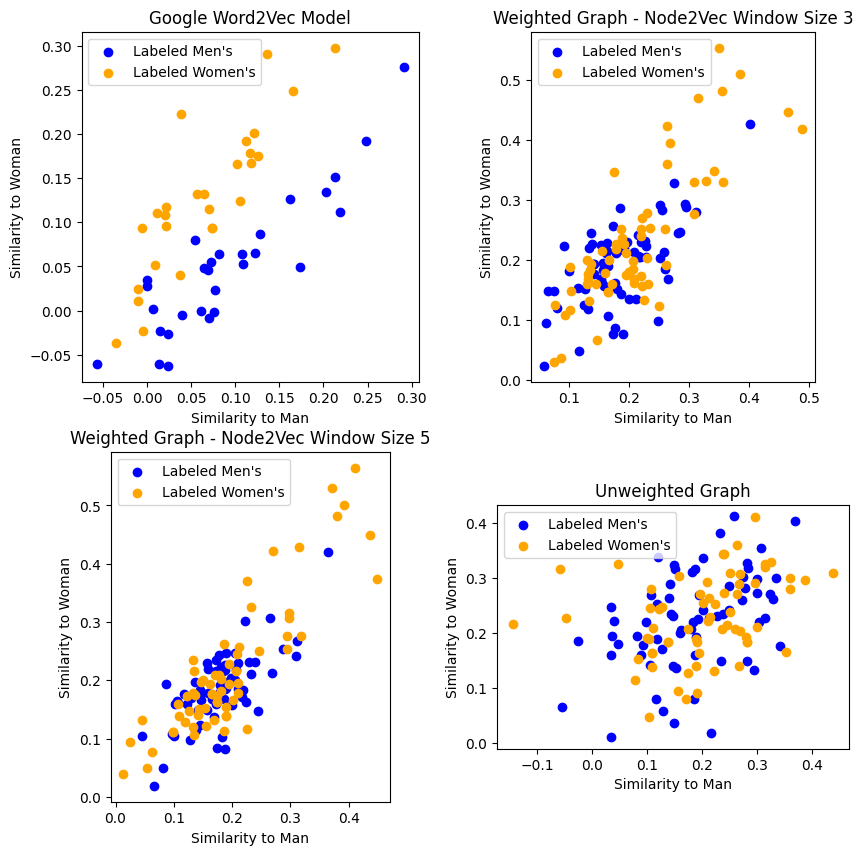

In [233]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
i, j = (0, 0)
for model_key, model in tqdm(models.items()):
    if model_key != 'google_word2vec':  
        man_key = "('man', 'n', 'singular', 'common')"
        woman_key = "('woman', 'n', 'singular', 'common')"
    else:
        man_key = 'man'
        woman_key = 'woman'
        
    man_emb = model[man_key]
    woman_emb = model[woman_key]
    magnitude_man = np.linalg.norm(man_emb)
    magnitude_woman = np.linalg.norm(woman_emb)

    mens_x = []
    mens_y = []

    womens_x = []
    womens_y = []
    
    for item in mens + womens:
        if model_key != 'google_word2vec':  
            nodes = [node for node in get_nodes(graph_weighted, item) if 'UNK_POS' not in node]
        else:
            nodes = [item]

        for node in nodes:
            item_emb = model[node]
            magnitude_item = np.linalg.norm(item_emb)
            
            similarity_man = np.dot(item_emb, man_emb) / (magnitude_man * magnitude_item)
            similarity_woman = np.dot(item_emb, woman_emb) / (magnitude_woman * magnitude_item)
            #ax.annotate(node, (similarity_man, similarity_woman), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=8)
            if item in mens:
                mens_x.append(similarity_man)
                mens_y.append(similarity_woman)
            else:
                womens_x.append(similarity_man)
                womens_y.append(similarity_woman)

    ax = axs[i,j]
    ax.scatter(mens_x, mens_y, color='blue', label='Labeled Men\'s')
    ax.scatter(womens_x, womens_y, color='orange', label='Labeled Women\'s')
    ax.legend()
    ax.set_xlabel('Similarity to Man')
    ax.set_ylabel('Similarity to Woman')
    ax.set_title(plot_titles[model_key])
    ax.set_aspect('equal', adjustable='box')

    j = (j + 1) % 2
    if j == 0:
        i += 1
    
plt.savefig('plot_of_bias.png')

In [208]:
Word2Vec.load("embeddings.model").wv

### Visualizing Embeddings

In [ ]:
def my_generator():
    # Your generator logic here
    for item in model.wv:
        try:
            # Yield the item from the generator
            yield item
        
        except SomeSpecificException:  # Replace 'SomeSpecificException' with the actual exception you expect
            # Handle the exception or skip problematic items
            pass

In [215]:
def proj_vec(vec, dim_x=0, dim_y=1):
    i = np.zeros(200)
    j = np.zeros(200)
    i[dim_x] = 1
    j[dim_y] = 1
    return np.dot(vec, i), np.dot(vec, j)

def get_projections(keys, dim_x=0, dim_y=1):
    x_s = []
    y_s = []
    centroid = None
    for key in keys:
        vec = model.wv[key]
        if centroid is None:
            centroid = vec.copy()
        else:
            centroid += vec
            
        x, y = proj_vec(vec, dim_x, dim_y)
        x_s.append(x)
        y_s.append(y)

    centroid = centroid / len(keys)
    return x_s, y_s, proj_vec(centroid, dim_x, dim_y)
            


In [192]:
meta_nodes = [node for node in graph.nodes if "'meta'" in node]
meta_x, meta_y = get_projections(meta_nodes)

In [222]:
def plot_embeddings(w1, r1, w2, r2, n=6, cols=3):
    colors = ['blue', 'red', 'orange', 'green', 'purple']
    dims = [np.random.randint(0,200, size=2) for i in range(n)]
    fig, axis = plt.subplots(int(np.ceil(n/cols)), cols, figsize=(10, 10))
    i, j = 0, 0
    for x_dim, y_dim in tqdm(dims, 'creating plots...'):
        axis[i, j].scatter(x_s, y_s)
        axis[i, j].set_title(f'dims: {x_dim, y_dim}')
        
        projections = {}
        k = 0
        for word in [w1, r1, w2, r2]:
            word_xs, word_ys, centroid = get_projections(get_nodes(word), x_dim, y_dim)
            centroid_x, centroid_y = centroid
            axis[i, j].scatter(word_xs, word_ys, label=word, marker='o', color=colors[k])
            axis[i, j].scatter([centroid_x], [centroid_y], marker='*', s=200, color=colors[k])
            k += 1

        axis[i,j].legend()
        j = (j + 1) % cols
        if j == 0:
            i += 1
        
            

creating plots...: 100%|█████████████████████████████████████████████████████████████████| 6/6 [00:12<00:00,  2.10s/it]


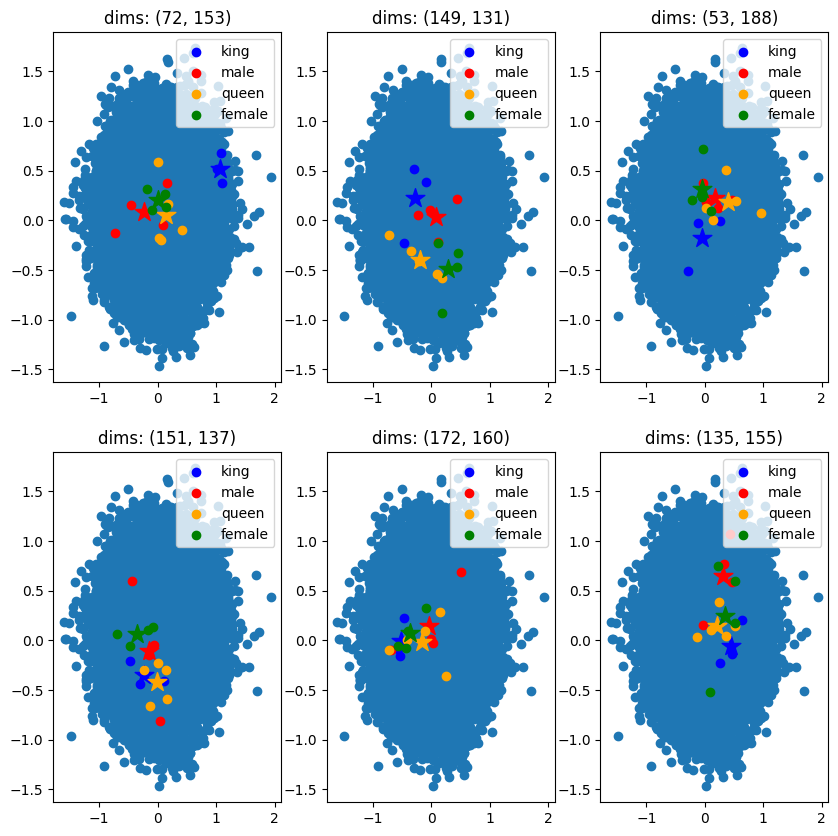

In [223]:
plot_embeddings('king', 'male', 'queen', 'female')

In [120]:
num_synsets = len(list(wn.all_synsets()))

In [130]:
model.wv.most_similar(get_nodes('african', 'proper')[0])

[("('africans', 'n', 'plural', 'proper')", 0.6300942301750183),
 ("('genus_emilia', 'n', 'plural', 'common')", 0.6273725628852844),
 ("('emilia', 'n', 'plural', 'common')", 0.625086784362793),
 ("('widow_bird', 'n', 'singular', 'common')", 0.6126163005828857),
 ("('widow_bird', 'n', 'singular', 'proper')", 0.6111546754837036),
 ("('whydah', 'n')", 0.6110675930976868),
 ("('whydah', 'n', 'singular', 'proper')", 0.6103405356407166),
 ("('whidah', 'n', 'singular', 'proper')", 0.6096197366714478),
 ("('harpullia', 'n', 'singular', 'common')", 0.6054715514183044),
 ("('whydah', 'n', 'singular', 'common')", 0.6024436950683594)]

In [131]:
path = walks[0]

NameError: name 'walks' is not defined

### PageRank

In [ ]:
graph_non_weighted = nx.read_gexf('pos_tagged_graph_original.gexf')

In [ ]:
nx.pagerank(graph)